In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import string
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.diagnostics import (
    avg_windows,
    R_hat
)

from flonacomldft.utils.io_utils import (
    get_project_path,
    get_path
)

import matplotlib as mlp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.transforms import Bbox
import seaborn as sns
import cmocean.cm as cmo

from flonacomldft.utils.plots import (
    load_ag6_image
)

from ase.units import kB
from scipy.stats import linregress

In [5]:
np.random.seed(42)

In [6]:
sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.1,

            # Use serif fonts
            #'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

methods_color = dict(zip(['ab-flowMC w.o. MLP', 'MD', 'ab-flowMC',  
                          'Pretrained ab-flowMC', 
                        'ab-flowMM w.o. MLP', 'ab-flowMM', 'MCMC w. flow from MD'],
                        ['#0077BB', '#cdb332',  '#CC3311',  
                        '#000000',
                        '#0077BB', '#CC3311', '#cdb332']
                        ))

sns.color_palette(methods_color.values())


[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902),
 (0.8, 0.2, 0.06666666666666667),
 (0.0, 0.0, 0.0),
 (0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902)]

# 1. Figure ab-flowMC

In [61]:
def set_plot_figure_1(
    isomer,
    cvs,
    mlp_predictions,
    accs_rate,
    rhat,
    colors,
    figsize=(6*3, 3*3),
    fontsize=22,
    size_axes_label=22,
    size_tick_label=22,
    size_legend=17,
    linewidth=2,
    markersize=6,
    hspace=0.6,
    wspace=0.6,
):
    
    ncols = 4
    nrows = 2

    sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_legend,
                        }) 

    # -- set figure --

    fig, axs = plt.subplots(ncols=ncols, 
                    nrows=nrows, 
                    figsize=figsize,
                    gridspec_kw={'wspace': wspace,
                                'hspace': hspace})

    # -- set subplots --

    gs = axs[0, 0].get_gridspec()

    for ax in axs[:2, :2].ravel():
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :2])

    ax1 = axs[0][2]
    ax2 = axs[0][3]
    ax3 = axs[1][2]
    ax4 = axs[1][3]

    l, b, h, w = axbig.get_position().get_points().flatten()
    ax_mol = fig.add_axes([l + w*0.15, b + h*0.9, w*0.4, h*0.4])

    props = dict(boxstyle='round', facecolor='darkslategray', alpha=0.8)
    ax_mol.text([0.4, 0.4][isomer], [2.2, 2.15][isomer], 'Isomer {:d}'.format(isomer), transform=ax.transAxes, fontsize=size_legend*1.25,
        verticalalignment='top', bbox=props, c='white')

    # -- subplot for energy --

    ax_energies = fig.add_axes([l*1.4, b*1.8, w*0.1, h*0.35])

    # -- item to subplot and delete top and right axis lines --

    for n, ax in enumerate([axbig, ax1, ax2, ax3, ax4]):
        if n==0:
            posx = -0.1
            posy = 1.05
        else:
            posx = -0.35
            posy = 1.15
        ax.text(posx,
        posy, 
        string.ascii_uppercase[n], 
        transform=ax.transAxes, 
        weight='bold')
        
        ax.spines[['right', 'top']].set_visible(False)

    axbig.spines[['right', 'top']].set_visible(False)
    ax_mol.set_axis_off()
        
    # -- plot isomer image --
    
    ax_mol.imshow(load_ag6_image(isomer))

    # -- plot cvs (density) --
    
    sns.kdeplot(
        data=cvs[cvs['Method'] == 'ab-flowMC w.o. MLP'], 
        x='C', 
        y='R',
        hue='Method',
        fill=False, 
        common_norm=False,
        linewidths=linewidth*1.1,
        linestyles='--',
        ax=axbig,
        levels=6,
        )

    # -- plot cvs (samples) -- 
    for method in [ "ab-flowMC", "MD"]:
        sns.scatterplot(
            data=cvs[cvs['Method'] == method], #!= 'ab-flowMC w.o. MLP'],
            x='C', 
            y='R', 
            hue='Method',
            style='Method',
            ax=axbig,
            palette=colors,
            s=markersize*15,
            zorder=2.5,
            #hue_order=[ "MD", "ab-flowMC"],
            markers='o',
            alpha=1,
            legend=True,
        )
    
    markers = ['o', '', 'o']
    linestyles = ['', 'dashed', '']
    
    patches = [ axbig.plot([],[], 
                               marker=markers[i],  
                               linestyle=linestyles[i],
                               markersize=markersize,
                               linewidth=linewidth, 
                               color=colors[key], 
                label="{:s}".format(key) )[0]  for i, key in enumerate(cvs['Method'].unique()[:3]) ]
    
    axbig.legend(handles=patches)
    axbig.set_xlabel('Coordination number')
    axbig.set_ylabel('Radius of gyration')

    # -- plot energies --

    sns.histplot(data=cvs,
                stat='density',
                x='U',
                hue='Method',
                bins=20,
                alpha=1,
                palette=colors,
                element='step',
                linewidth=linewidth,
                fill=False,
                ax=ax_energies,
                common_bins=False, 
                common_norm=False,
                legend=False, 
                )

    ax_energies.set_xlim(cvs['U'].min(), cvs['U'].max())

    ax_energies.set_ylabel('Density (u.a.)', fontsize=size_legend)
    ax_energies.set_xlabel('Potential energy (eV)', fontsize=size_legend)
    ax_energies.xaxis.set_tick_params(labelsize=size_legend)
    ax_energies.yaxis.set_tick_params(labelsize=size_legend)


    # -- plot MLP predictions --

    energy_max = cvs['U'].max()
    mlp_predictions = mlp_predictions[mlp_predictions['True values'] < energy_max]  

    palette_predictions = dict(zip(['Train', 'Test'], 
                                    ['#8f230b', '#f27e64']
                                    ))
    
    points = {'x': np.array([mlp_predictions['True values'].min(),
                  energy_max-0.05]),
            'y': np.array([mlp_predictions['True values'].min(), 
                  energy_max-0.05])}
    
    sns.lineplot(points,
                x='x',
                y='y',
                linestyle='--',
                color='k',
                linewidth=linewidth,
                ax=ax1,)
    
    sns.scatterplot(data=mlp_predictions,
                x='True values',
                y='Predictions',
                hue='Dataset',
                style='Dataset',
                markers=['p', 'X'],
                palette=palette_predictions,
                s=markersize*10,
                zorder=2.5,
                ax=ax1)

    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles=handles, labels=['Train', 'Test'], fontsize=size_legend*0.75)

    ax1.set_xlabel('Potential energy (eV)')
    ax1.set_ylabel('Predictions (eV)')

    # -- plot accs --

    accs_rate_avg = []

    for simulation in accs_rate['Method'].unique():
        df = accs_rate[accs_rate['Method'] == simulation]
        df_new = pd.DataFrame(columns=accs_rate.columns)
    
        df_new['Acceptance Rate'] = avg_windows(
            df['Acceptance Rate'], 
            window_size=40, 
            axis=1)
        df_new['Step'] = avg_windows(
            df['Step'],
            window_size=40, 
            axis=1)
        df_new['Method'] = simulation
        df_new['Isomer'] = accs_rate['Isomer'].unique()[0]
        accs_rate_avg.append(df_new)
    
    accs_rate_avg = pd.concat(accs_rate_avg)
    
    sns.lineplot(accs_rate, 
                x='Step', 
                y='Acceptance Rate', 
                hue='Method',
                palette=methods_color, 
                alpha=0.1,
                ax=ax2,
                legend=False) 
    
    sns.lineplot(accs_rate_avg,
                x='Step', 
                y='Acceptance Rate', 
                hue='Method',
                palette=methods_color, 
                linewidth=linewidth,
                ax=ax2,
                legend=False)

    ax2.set_ylabel("Acceptance rate")
    ax2.set_xlabel("Steps")

    #ax2.plot([], [], '-k', label='Ab-flowMC w. pretrained MLP')

    patches = [ ax2.plot([],[],  
                               #linestyle='dashed', 
                               linewidth=linewidth, 
                               color='k', 
                label="{:s}".format('ab-flowMC w. \npretrained MLP') )[0] ]
    
    ax2.legend(handles=patches, fontsize=size_legend*0.75)
            

    # -- plot rhat steps and time --

    markers = ['o', 's', '^']
    linestyles = ['dashed', 'dotted', '-']
    labels = ['Coordination \n number', 'Radius \n of gyration', 'Potential \n energy']
    columns = ['C', 'R', 'U']
            
    for key in rhat['Method'].unique()[::-1]:
        df = rhat[rhat['Method'] == key]
        for i in range(3):
            sns.lineplot(df,
                        x='MCMC step', 
                        y=columns[i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=labels[i],
                        ax=ax3,
                        legend=False)
            
            sns.lineplot(df,
                        x='Time (h)', 
                        y=columns[i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize*1.4,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=labels[i],
                        ax=ax4,
                        legend=False)
    
    ax3.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax3.set_xlabel('Steps')
    ax3.set_ylabel(r'$\hat{R}$')

    ax4.axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    ax4.set_xlabel('Time (h)')
    ax4.set_ylabel(r'$\hat{R}$')

    ax4.set_xscale('log')
    ax4.set_ylim(1, 1.05)
    ax4.set_xlim(left=9)

    ax4.set_xticks([10, 50, 100])
    ax4.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

    # -- plot rhat legend --

    patches = [ ax3.plot([],[], 
                               marker=markers[i], 
                               linestyle=linestyles[i], 
                               linewidth=linewidth, 
                               markersize=markersize, 
                               color='gray', 
                label="{:s}".format(labels[i]) )[0]  for i in range(3) ]
    
    patches = patches + [ ax3.plot([],[],  
                               linestyle='dashed', 
                               linewidth=linewidth, 
                               color='gray', 
                label="{:s}".format('Threshold \n 1.01') )[0] ]
    
    ax3.legend(handles=patches, fontsize=size_legend*0.75)

    # -- set formatter axis --
 
    axbig.xaxis.set_major_locator(plt.MaxNLocator(4))
    axbig.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    axbig.yaxis.set_major_locator(plt.MaxNLocator([4, 2][isomer]))
    axbig.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    ax3.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    #ax4.xaxis.set_major_locator(plt.MaxNLocator(1))
    #ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    ax_energies.xaxis.set_major_locator(plt.MaxNLocator(2))
    ax_energies.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    #fig.suptitle(f'Isomer {isomer}', fontsize=22)    

In [17]:
path_datasets = get_project_path() + '/database/andersen/datasets'
path_results = get_project_path() + '/figures/preprint_v2/data'
path_save_figures = get_project_path() + '/figures/preprint_v2/plots'

In [18]:
print('Loading data...')

N_input_samples = 500

md_samples_is0 = pd.read_csv(path_datasets + '/is0_flow_train.csv').rename(
            columns={'potential_energy': 'U'})[:N_input_samples][['U', 'C', 'R']]
md_samples_is0['Isomer'] = 0
md_samples_is0['Method'] = 'MD'

md_samples_is1 = pd.read_csv(path_datasets + '/is1_flow_train.csv').rename(
            columns={'potential_energy': 'U'})[:N_input_samples][['U', 'C', 'R']]
md_samples_is1['Isomer'] = 1
md_samples_is1['Method'] = 'MD'

md_samples = pd.concat([md_samples_is0, md_samples_is1])
mcmc_samples = pd.read_csv(path_results + '/cvs_potential_energy.csv')
accs_rates = pd.read_csv(path_results + '/acceptance_rates.csv')
rhat_values = pd.read_csv(path_results + '/rhat.csv')
mlp_datasets = pd.read_csv(path_results + '/mlp_datasets.csv')

pretrained_accs_rates = pd.read_csv(path_results + '/pretrained_acceptance_rates.csv')
pretrained_rhat_values = pd.read_csv(path_results + '/pretrained_rhat.csv')

Loading data...


In [19]:
accs_rates = pd.concat([accs_rates, pretrained_accs_rates])
rhat_values = pd.concat([rhat_values, pretrained_rhat_values])
rhat_values

,C,R,U,Time (h),MCMC step,Method,Isomer
0,1.114298,1.135346,1.110416,6.130083,90,ab-flowMC,0
1,1.072752,1.064500,1.054616,9.483880,180,ab-flowMC,0
2,1.041248,1.039257,1.039189,11.651488,270,ab-flowMC,0
3,1.034388,1.028895,1.028274,13.651694,360,ab-flowMC,0
4,1.024605,1.022147,1.022185,15.657979,450,ab-flowMC,0
5,1.018917,1.018480,1.018093,17.700629,540,ab-flowMC,0
6,1.015433,1.015258,1.013192,19.740342,630,ab-flowMC,0
7,1.012795,1.013567,1.011050,21.806306,720,ab-flowMC,0
8,1.009842,1.011784,1.010485,23.705137,810,ab-flowMC,0
9,1.008763,1.009829,1.008933,25.739646,900,ab-flowMC,0


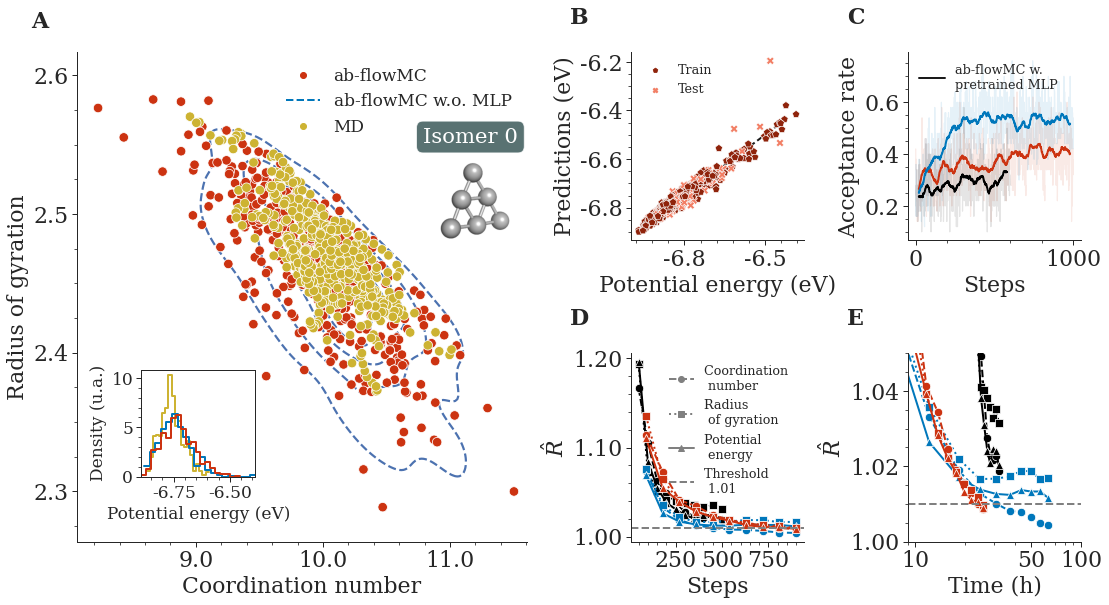

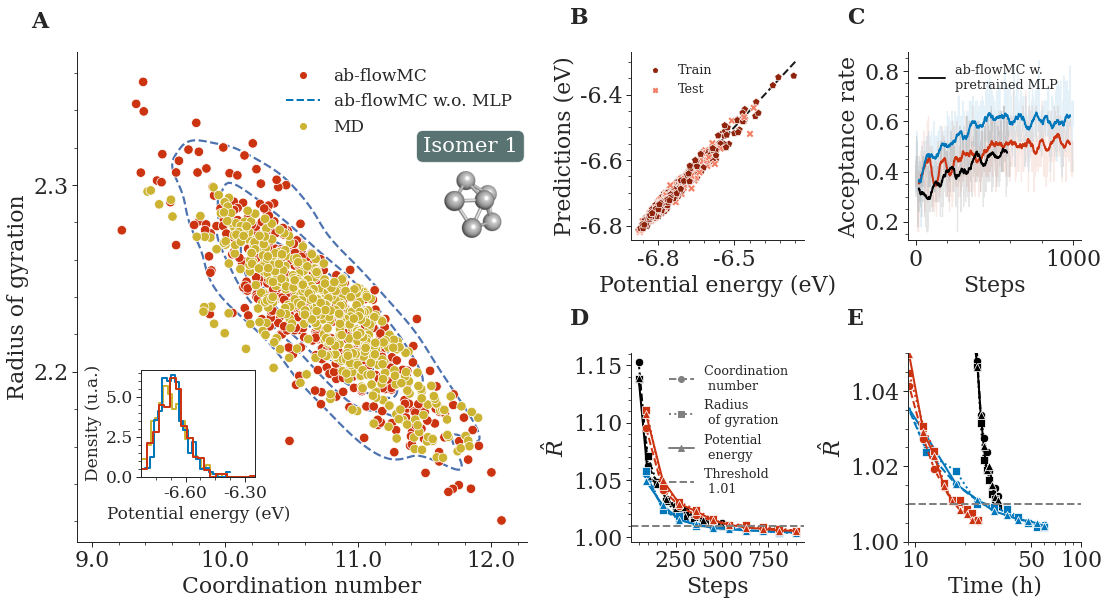

In [62]:
np.random.seed(42)

for isomer in [0, 1]:

    md = md_samples[md_samples['Isomer'] == isomer]
    abflowmc = mcmc_samples[mcmc_samples['Method'] == 'ab-flowMC']
    abflowmc = abflowmc[abflowmc['Isomer'] == isomer]
    abflowmc_womlp = mcmc_samples[mcmc_samples['Method'] == 'ab-flowMC w.o. MLP']
    abflowmc_womlp = abflowmc_womlp[abflowmc_womlp['Isomer'] == isomer]

    cvs = pd.concat([
        abflowmc.sample(N_input_samples),
        abflowmc_womlp.sample(N_input_samples),
        md,
    ])

    mlp_predictions = mlp_datasets[
        mlp_datasets['Isomer'] == isomer
        ].sample(N_input_samples*2)

    accs_rate = accs_rates[accs_rates['Isomer'] == isomer]

    rhat = rhat_values[rhat_values['Isomer'] == isomer]

    set_plot_figure_1(
                    isomer=isomer,
                    cvs=cvs,
                    mlp_predictions=mlp_predictions,
                    accs_rate=accs_rate,
                    rhat=rhat, 
                    colors=methods_color)
    
    plt.savefig(path_save_figures + f'/figure_ab-flowMC_isomer_{isomer}_labeled.pdf', 
    #plt.savefig(path_save_figures + f'/figure_ab-flowMC_isomer_{isomer}.pdf', 
                bbox_inches='tight',
                dpi=300, 
                facecolor='white', 
                transparent=False)

# 2. Figure Optical spectra

In [79]:
opt_data = pd.read_csv(path_results + '/optical_spectra.csv')

In [80]:
opt_spc_colors = dict(zip(['T=OK', 'MD', 'ab-flowMC', 'ab-flowMC w.o. MLP'],
                        ['#808080', '#cdb332', '#CC3311', 
                        '#0077BB']))

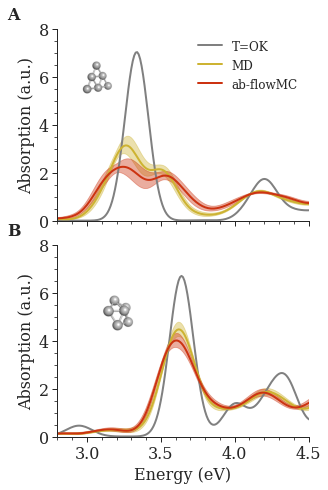

In [81]:
figsize=(4.5*1, 3.75*2)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.125
wspace=0.0

ncols = 1
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0]
ax2 = axs[1]

# -- item to subplot and delete top and right axis lines --

posx = -0.2
posy = 1.05

for n, ax in enumerate([ax1, ax2]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

n=50

from scipy.stats import t
t = t.ppf(1-0.05/2, n-1)

for i in range(2):
    
    sns.lineplot(#data=opt_data['T0K_is'+str(i)+'_dft'],
            x=opt_data['energy'],
            y=opt_data['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_md'] - t*opt_data['std_350K_is'+str(i)+'_md'], 
        opt_data['mean_350K_is'+str(i)+'_md'] + t*opt_data['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_mlp'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['ab-flowMC'],
            label='ab-flowMC'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_mlp'] - t*opt_data['std_350K_is'+str(i)+'_mlp'], 
        opt_data['mean_350K_is'+str(i)+'_mlp'] + t*opt_data['std_350K_is'+str(i)+'_mlp'], 
        color=opt_spc_colors['ab-flowMC'], alpha=0.4)         

# -- set the limits of x and y axis --

ax1.set_ylabel('Absorption (a.u.)')
ax2.set_ylabel('Absorption (a.u.)')

for i in range(2):

    axs[i].set_xlabel('Energy (eV)')

    axs[i].set_xlim(2.8, 4.5)
    axs[i].set_ylim(0, 8)

ax1.legend()
ax2.legend().remove()
ax1.set(xlabel=None)

# -- add image isomer --

l, b, h, w = ax1.get_position().get_points().flatten()
axsmall_1 = fig.add_axes([l*1.35, b*1.35, h*0.175, w*0.175])
axsmall_1.imshow(load_ag6_image(0))
axsmall_1.set_axis_off()

l, b, h, w = ax2.get_position().get_points().flatten()
axsmall_2 = fig.add_axes([l*1.65, b*2.35, h*0.245, w*0.245])
axsmall_2.imshow(load_ag6_image(1))
axsmall_2.set_axis_off()

#ax1.set_aspect('equal')
#ax2.set_aspect('equal')

# -- sharing axis subplots --

ax2.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

plt.savefig(path_save_figures+'/figure_3_optical.pdf',
            dpi=300, 
            facecolor='white',
            transparent=False)

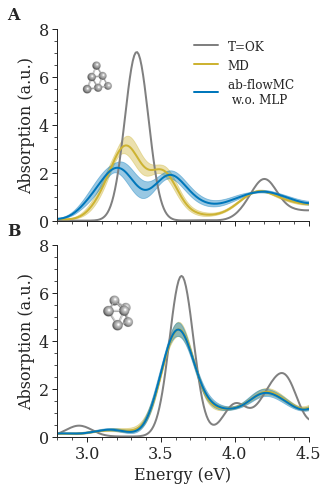

In [82]:
figsize=(4.5*1, 3.75*2)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.125
wspace=0.0

ncols = 1
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0]
ax2 = axs[1]

# -- item to subplot and delete top and right axis lines --

posx = -0.2
posy = 1.05

for n, ax in enumerate([ax1, ax2]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

n=50

from scipy.stats import t
t = t.ppf(1-0.05/2, n-1)

for i in range(2):
    
    sns.lineplot(#data=opt_data['T0K_is'+str(i)+'_dft'],
            x=opt_data['energy'],
            y=opt_data['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_md'] - t*opt_data['std_350K_is'+str(i)+'_md'], 
        opt_data['mean_350K_is'+str(i)+'_md'] + t*opt_data['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['ab-flowMC w.o. MLP'],
            label='ab-flowMC \n w.o. MLP'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_dft'] - t*opt_data['std_350K_is'+str(i)+'_dft'], 
        opt_data['mean_350K_is'+str(i)+'_dft'] + t*opt_data['std_350K_is'+str(i)+'_dft'], 
        color=opt_spc_colors['ab-flowMC w.o. MLP'], alpha=0.4)  
    

# -- set the limits of x and y axis --

ax1.set_ylabel('Absorption (a.u.)')
ax2.set_ylabel('Absorption (a.u.)')

for i in range(2):

    axs[i].set_xlabel('Energy (eV)')

    axs[i].set_xlim(2.8, 4.5)
    axs[i].set_ylim(0, 8)

ax1.legend()
ax2.legend().remove()
ax1.set(xlabel=None)

# -- add image isomer --

l, b, h, w = ax1.get_position().get_points().flatten()
axsmall_1 = fig.add_axes([l*1.35, b*1.35, h*0.175, w*0.175])
axsmall_1.imshow(load_ag6_image(0))
axsmall_1.set_axis_off()

l, b, h, w = ax2.get_position().get_points().flatten()
axsmall_2 = fig.add_axes([l*1.65, b*2.35, h*0.245, w*0.245])
axsmall_2.imshow(load_ag6_image(1))
axsmall_2.set_axis_off()

#ax1.set_aspect('equal')
#ax2.set_aspect('equal')

# -- sharing axis subplots --

ax2.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

plt.savefig(path_save_figures+'/figure_3_optical_wo_MLP.pdf',
            dpi=300, 
            facecolor='white',
            transparent=False)

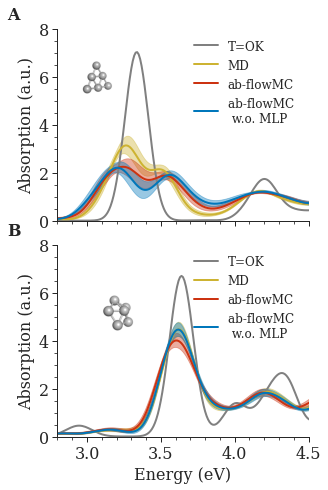

In [84]:
figsize=(4.5*1, 3.75*2)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.125
wspace=0.0

ncols = 1
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0]
ax2 = axs[1]

# -- item to subplot and delete top and right axis lines --

posx = -0.2
posy = 1.05

for n, ax in enumerate([ax1, ax2]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

n=50

from scipy.stats import t
t = t.ppf(1-0.05/2, n-1)

for i in range(2):
    
    sns.lineplot(#data=opt_data['T0K_is'+str(i)+'_dft'],
            x=opt_data['energy'],
            y=opt_data['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    #axs[i].errorbar(opt_data['energy'],
    #                opt_data['mean_350K_is'+str(i)+'_md'],
    #                yerr=t*opt_data['std_350K_is'+str(i)+'_md'],
    #                color=opt_spc_colors['MD'],
    #                label='MD')

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_md'] - t*opt_data['std_350K_is'+str(i)+'_md'], 
        opt_data['mean_350K_is'+str(i)+'_md'] + t*opt_data['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_mlp'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['ab-flowMC'],
            label='ab-flowMC'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_mlp'] - t*opt_data['std_350K_is'+str(i)+'_mlp'], 
        opt_data['mean_350K_is'+str(i)+'_mlp'] + t*opt_data['std_350K_is'+str(i)+'_mlp'], 
        color=opt_spc_colors['ab-flowMC'], alpha=0.4)

    sns.lineplot(x=opt_data['energy'],
            y=opt_data['mean_350K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['ab-flowMC w.o. MLP'],
            label='ab-flowMC \n w.o. MLP'
            )
    
    axs[i].fill_between(
        opt_data['energy'], 
        opt_data['mean_350K_is'+str(i)+'_dft'] - t*opt_data['std_350K_is'+str(i)+'_dft'], 
        opt_data['mean_350K_is'+str(i)+'_dft'] + t*opt_data['std_350K_is'+str(i)+'_dft'], 
        color=opt_spc_colors['ab-flowMC w.o. MLP'], alpha=0.4) 
    

# -- set the limits of x and y axis --

ax1.set_ylabel('Absorption (a.u.)')
ax2.set_ylabel('Absorption (a.u.)')

for i in range(2):

    axs[i].set_xlabel('Energy (eV)')

    axs[i].set_xlim(2.8, 4.5)
    axs[i].set_ylim(0, 8)

ax1.legend()
#ax2.legend().remove()
ax1.set(xlabel=None)

# -- add image isomer --

l, b, h, w = ax1.get_position().get_points().flatten()
axsmall_1 = fig.add_axes([l*1.35, b*1.35, h*0.175, w*0.175])
axsmall_1.imshow(load_ag6_image(0))
axsmall_1.set_axis_off()

l, b, h, w = ax2.get_position().get_points().flatten()
axsmall_2 = fig.add_axes([l*1.65, b*2.35, h*0.245, w*0.245])
axsmall_2.imshow(load_ag6_image(1))
axsmall_2.set_axis_off()

#ax1.set_aspect('equal')
#ax2.set_aspect('equal')

# -- sharing axis subplots --

ax2.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

plt.savefig(path_save_figures+'/figure_3_optical_all.pdf',
            dpi=300, 
            facecolor='white',
            transparent=False)

# 3. Figure ab-flowMM

In [43]:
mcmc_samples_mm = pd.read_csv(path_results + '/cvs_potential_energy_mm.csv')
accs_rates_mm = pd.read_csv(path_results + '/acceptance_rates_mm.csv')
rhat_values_mm = pd.read_csv(path_results + '/rhat_mm.csv')
isomers_jumps_mm = pd.read_csv(path_results + '/isomers_jumps_mm.csv')
populations_values = pd.read_csv(path_results + '/populations_mm.csv')
density_samples_mm = pd.read_csv(path_results + '/density_samples_mm.csv')
time_slices_abflowmc = pd.read_csv(path_results + '/time_ab-flowMC.csv')
time_slices_abflowmc = time_slices_abflowmc[time_slices_abflowmc['Slice']==15]

In [44]:
time_slices_mm = []

for simulation_mm, simulation_mc in zip(rhat_values_mm['Method'].unique(), time_slices_abflowmc['Method'].unique()):
    time_slices = time_slices_abflowmc[time_slices_abflowmc['Method']==simulation_mc]['Time (h)'].sum()
    for i in range(10):
        time_slices_mm.append(time_slices)

rhat_values_mm['Time (h) ab-flowMC'] = time_slices_mm

In [45]:
rhat_values_mm['Total Time (h)'] = rhat_values_mm['Time (h)'] + rhat_values_mm['Time (h) ab-flowMC']

In [46]:
rhat_values_mm

,C,R,U,Time (h),MCMC step,Method,Time (h) ab-flowMC,Total Time (h)
0,1.124139,1.204832,1.133023,3.722343,540,ab-flowMM,24.797021,28.519363
1,1.082357,1.130364,1.099439,7.409369,1080,ab-flowMM,24.797021,32.206389
2,1.057328,1.108328,1.102443,11.699836,1620,ab-flowMM,24.797021,36.496857
3,1.062114,1.071262,1.076660,16.171329,2160,ab-flowMM,24.797021,40.968350
4,1.035192,1.053587,1.053765,21.159436,2700,ab-flowMM,24.797021,45.956457
5,1.030137,1.050895,1.050456,27.602615,3240,ab-flowMM,24.797021,52.399635
6,1.020906,1.042027,1.045628,34.409327,3780,ab-flowMM,24.797021,59.206347
7,1.017074,1.029584,1.034472,43.340674,4320,ab-flowMM,24.797021,68.137695
8,1.017215,1.025265,1.023948,52.482701,4860,ab-flowMM,24.797021,77.279721
9,1.022070,1.026578,1.027011,64.480958,5401,ab-flowMM,24.797021,89.277978


In [47]:
#populations_values

[ 40  48  57  71  91 121] [ 35  40  45  48  55  57  65  71  75  85  91  95 105 115 121 125 135]


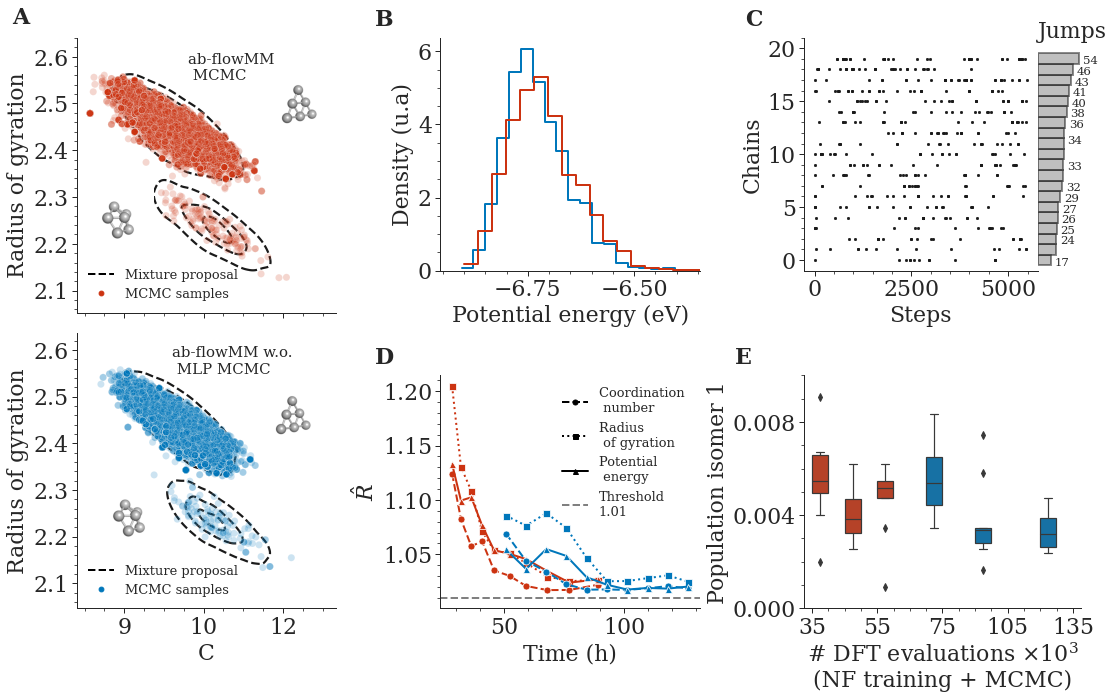

In [48]:
figsize=(6*3, 3.5*3)
fontsize=22
size_axes_label=22
size_tick_label=22
size_legend=13
linewidth=2
markersize=5
hspace=0.45
wspace=0.6

ncols = 4
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })   

# -- set figure --

fig, axs = plt.subplots(ncols=ncols, 
                nrows=nrows, 
                figsize=figsize,
                gridspec_kw={'width_ratios': [1.5, 1.5, 0.75, 0.25],
                'height_ratios': [1, 1],
                'wspace': wspace,
                'hspace': hspace}
                )
 
# -- set subplots --

# -- cvs subplots --

ax1 = axs[0][0]
ax4 = axs[1][0]

axs_scatter = [ax1, ax4]

# -- energies and isomers subplots --

ax2 = axs[0][1]

ax3 = axs[0][2]
ax_small = axs[0][3]

# -- rhats and populations subplots --

ax5 = axs[1][1]

gs_ax = axs[1][2].get_gridspec()
axs[1][2].remove()
axs[1][3].remove()

ax6 = fig.add_subplot(gs_ax[1, 2:])

# -- item to subplot and delete top and right axis lines --

posx = -0.25
posy = 1.05

for n, ax in enumerate([ax1, ax2, ax3, ax5, ax6]):
    
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

ax4.spines[['right', 'top']].set_visible(False)
ax_small.spines[['left', 'right', 'top']].set_visible(False)

# -- sharing axis subplots --

ax4.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

ax3.sharey(ax_small)

# -- update positions --

    # -- updating cvs plot size -- 

diff = ax1.get_position().get_points()[0][1] - ax4.get_position().get_points()[1][1]

ax1.set_position(Bbox(ax1.get_position().get_points() - np.array([[0, 1], [0, 0]])*(diff/2)*0.8))
ax4.set_position(Bbox(ax4.get_position().get_points() + np.array([[0, 0], [0, 1]])*(diff/2)*0.8))

#ax1.text(10.2, 2.55, 'ab-flowMM \n MCMC', fontsize=size_legend*1.15)
#ax4.text(9.9, 2.55, 'ab-flowMM w.o. \n MLP MCMC', fontsize=size_legend*1.15)


    # -- updating isomers plot size --

update_position = ax3.get_position().get_points()
update_position[1][0] = ax_small.get_position().xmin*1
ax3.set_position(Bbox(update_position))

# -- plot cvs (density) --

for key, ax in zip(density_samples_mm['Method'].unique(), [ax1, ax4]):

    sns.kdeplot(
        data=density_samples_mm[density_samples_mm['Method'] == key], 
        x='C', 
        y='R',
        fill=False, 
        common_norm=False,
        linewidths=linewidth*1.1,
        linestyles='--',
        ax=ax,
        levels=6,
        colors='k'
        )

    ax.plot([],[],   
            linestyle='dashed',
            linewidth=linewidth, 
            color='black', 
            label="Mixture proposal" )[0]

    ax.plot([],[],   
            #linestyle='dotted',
            linewidth=0,
            marker='o',
            color=methods_color[key], 
            label="MCMC samples" )

    df_samples = mcmc_samples_mm[mcmc_samples_mm['Method'] == key].sample(30000)
    sns.scatterplot(
            data=df_samples,
            x='C', 
            y='R', 
            hue='Method',
            ax=ax,
            palette=methods_color,
            s=markersize*10,
            alpha=0.2,
            zorder=2,
            legend=False,
        )
    
    ax.legend(loc='lower left')
    ax.set_ylabel('Radius of gyration')

ax1.text(10.2, 2.55, 'ab-flowMM \n MCMC', fontsize=size_legend*1.15)
ax4.text(9.9, 2.55, 'ab-flowMM w.o. \n MLP MCMC', fontsize=size_legend*1.15)

# -- plot structure --

l, b, h, w = ax1.get_position().get_points().flatten()
for i in range(2):
    ax_mol = fig.add_axes([l*[1.5, 0.3][i], b*np.array([1.45, 1.15])[i], w*[0.25, 0.275][i], h*[0.25, 0.275][i]])
    ax_mol.set_axis_off()
    ax_mol.imshow(load_ag6_image(i))

l, b, h, w = ax4.get_position().get_points().flatten()
for i in range(2):
    ax_mol = fig.add_axes([l*[1.85, 0.8][i], b*[2.7, 1.6][i], w*[0.25, 0.275][i], h*[0.25, 0.275][i]])
    ax_mol.set_axis_off()
    ax_mol.imshow(load_ag6_image(i))


# -- plot energy --

sns.histplot(data=mcmc_samples_mm,
            stat='density',
            x='U',
            hue='Method',
            bins=20,
            alpha=1,
            palette=methods_color,
            element='step',
            linewidth=linewidth,
            fill=False,
            ax=ax2, 
            common_bins=False, 
            common_norm=False,
            legend=False, 
            )

ax2.set_xlim(mcmc_samples_mm['U'].min()-0.05, 
             mcmc_samples_mm['U'].max()-0.1)

ax2.set_xlabel('Potential energy (eV)')
ax2.set_ylabel('Density (u.a)')

# -- plot rhat steps and time --

markers = ['o', 's', '^']
linestyles = ['dashed', 'dotted', '-']
labels = ['Coordination \n number', 'Radius \n of gyration', 'Potential \n energy']
columns = ['C', 'R', 'U']
        
for key in rhat_values_mm['Method'].unique():
    df = rhat_values_mm[rhat_values_mm['Method'] == key]
    for i in range(3):
        
        sns.lineplot(df,
                    x='Total Time (h)', 
                    y=columns[i], 
                    linestyle=linestyles[i], 
                    marker=markers[i],
                    markersize=markersize*1.4,
                    linewidth=linewidth,
                    color=methods_color[key], 
                    label=labels[i],
                    ax=ax5,
                    legend=False)

ax5.axhline(1.01, c='grey', ls='--', 
                linewidth=linewidth)

ax5.set_xlabel('Time (h)')
ax5.set_ylabel(r'$\hat{R}$')

#ax5.set_ylim(top=1.15)

# -- plot rhat legend --
        
patches = [ ax5.plot([],[], 
                           marker=markers[i], 
                           linestyle=linestyles[i], 
                           linewidth=linewidth, 
                           markersize=markersize, 
                           color='black', 
                           label="{:s}".format(labels[i]) )[0]  for i in range(len(columns)) ]

patches = patches + [ ax5.plot([],[],
                            linestyle='dashed', 
                            linewidth=linewidth, 
                            color='gray', 
                            label="{:s}".format('Threshold\n1.01') )[0] ]

ax5.legend(handles=patches)

# -- plot isomers --

isomers = isomers_jumps_mm[isomers_jumps_mm['Method'] == 'ab-flowMM']
isomers.drop(columns=['Step', 'Method'], inplace=True)
isomers = isomers.to_numpy()

z = isomers.T
horzSum = np.array([torch.unique_consecutive(torch.tensor(z[i])).shape[0] - 1 for i in range(20)])
index_sort = np.argsort(horzSum)

z = z[index_sort, :]
horzSum = horzSum[index_sort]

for i in range(z.shape[0]):
    mask = z[i]==1
    x = np.arange(0, z.shape[1], 1)
    y = np.ones(z.shape[1])*i
    
    ax3.scatter(x[mask], y[mask], s=5, marker='o', c='k')

ax_small.barh(np.array(range(len(horzSum))), 
        horzSum, 
        1, 
        color='gray', 
        edgecolor='k', 
        linewidth=linewidth, 
        alpha=0.5)

ax_small.text(0.8, 21, 'Jumps')

values, indexes, counts = np.unique(horzSum, return_index=True, return_counts=True)
counts[counts == 1] = 0

for index, value, count in zip(indexes, values, counts):
    ax_small.text(value + 5, 
                index - 0.5 + count/2,
                str(int(value)), 
                fontsize=size_legend*0.9)

ax3.set_ylim(-1, len(z)+1)
  
ax3.set_xlabel('Steps')
ax3.set_ylabel('Chains')

ax_small.set_axis_off()

# -- plot populations --

order_scale = np.unique(sorted(populations_values['# DFT evaluations'].unique().tolist() + list(range(35, 145, 10))))
#order_scale = np.arange(30, 100, 15)
print(np.unique(sorted(populations_values['# DFT evaluations'].unique().tolist())), order_scale)
sns.boxplot(populations_values,
            x='# DFT evaluations',
            y='means',
            hue='Method',
            palette=methods_color,
            order=order_scale,
            ax=ax6,
            width=2
            )

ax6.set_ylim(0, 0.01)
ax6.legend().remove()

ax6.set_ylabel('Population isomer 1')
ax6.set_xlabel(r'# DFT evaluations $\times$10$^3$' '\n' '(NF training + MCMC)')

ax6.yaxis.set_major_locator(plt.MaxNLocator(3))
ax6.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

#ax1.yaxis.set_major_locator(plt.MaxNLocator(4))
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

#ax4.yaxis.set_major_locator(plt.MaxNLocator(4))
ax4.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax4.xaxis.set_major_locator(plt.MaxNLocator(4))
ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

ax6.xaxis.set_major_locator(plt.MaxNLocator(5))
#ax6.yaxis.set_major_locator(plt.MaxNLocator(3))
#ax6.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.savefig(path_save_figures + f'/figure_2_mixture_time.pdf', 
            bbox_inches='tight',
            dpi=300, 
            facecolor='white', 
            transparent=False)

# Supplementary

## NLLs vs Us Proposals

In [49]:
nlls_df = pd.read_csv(path_results + '/nlls.csv')

(2500, 5)
0.6862680447850922 4.300068267020546
(2500, 5)
0.8456495852561196 5.392962575859417
(2500, 5)
0.8338628186533933 5.1481395988734455
(2500, 5)
0.8956299419398984 5.56576061895939


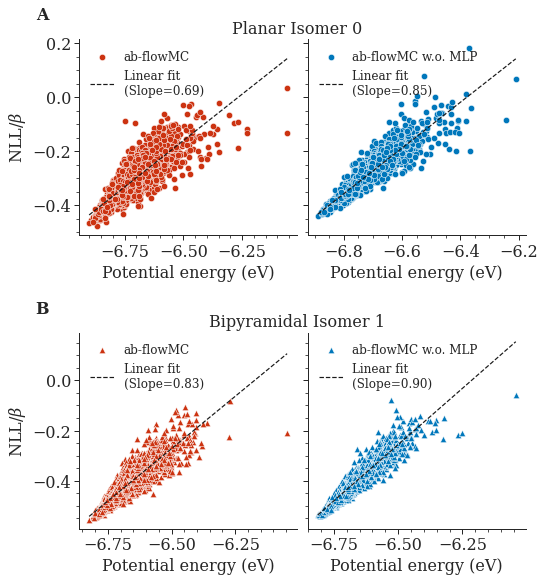

In [50]:
ncols = 2
nrows = 2

figsize=(4*ncols, 4.5*nrows)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=15
hspace=0.5
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

palettes = ['flare', 'crest']
markers = ['o', '^']

for i in [0, 1]:
    for j, method in enumerate(["ab-flowMC", "ab-flowMC w.o. MLP"]):
        df = nlls_df[nlls_df['Method'] == method]
        df['nlls'] = nlls_df['nlls']
        #df = df[df['Isomer'] == i][-10000:].sample(3000)
        df = df[df['Isomer'] == i][-5000:][::2]

        print(df.shape)

        slope, intercept, r, p, se = linregress(df['us'], df['nlls'])
        print(slope, intercept)

        y = slope*np.linspace(df['us'].min(), df['us'].max(), 100) + intercept

        #if len(method.split())>1:
        #    label = ' '.join(method.split()[:2]) + ' \n ' + method.split()[-1]
        #else:
        #    label = method

        sns.scatterplot(df,
        x='us',
        y='nlls',
        color=methods_color[method],
        label=method, 
        ax = axs[i][j],
        marker=markers[i],
        legend=True,
        s=40)

        sns.lineplot(x=np.linspace(df['us'].min(), df['us'].max(), 100), 
                    y=y,
                    color='k',
                    linestyle='--',
                    ax = axs[i][j], 
                    legend=False)

        axs[i][j].spines[['right', 'top']].set_visible(False)

        axs[i][j].plot([], [], linestyle='--',
                color='k',
                label='Linear fit \n(Slope={:.2f})'.format(slope))


axs[1][0].set_xlabel('Potential energy (eV)')
axs[1][1].set_xlabel('Potential energy (eV)')

axs[0][0].set_xlabel('Potential energy (eV)')
axs[0][1].set_xlabel('Potential energy (eV)')

axs[0][0].set_ylabel(r'NLL/$\beta$')
axs[1][0].set_ylabel(r'NLL/$\beta$')

axs[0][0].sharey(axs[0][1])
axs[1][0].sharey(axs[1][1])
plt.setp(axs[0][1].get_yticklabels(), visible=False)
plt.setp(axs[1][1].get_yticklabels(), visible=False)
axs[0][1].set(ylabel=None)
axs[1][1].set(ylabel=None)

posx = -0.2
posy = 1.1

for n, ax in enumerate([axs[0][0], axs[1][0]]):
    
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

axs[0][0].legend(loc='upper left')
axs[0][1].legend(loc='upper left')
axs[1][0].legend(loc='upper left')
axs[1][1].legend(loc='upper left')

axs[0][0].set_title('Planar Isomer 0', x=1)
axs[1][0].set_title('Bipyramidal Isomer 1', x=1)

plt.savefig(path_save_figures + f'/figure_4_nlls.pdf', 
            bbox_inches='tight',
            dpi=300, 
            facecolor='white',
            transparent=False)

## Loss NF

In [51]:
flow_losses_df = pd.read_csv(path_results + '/flow_losses.csv')

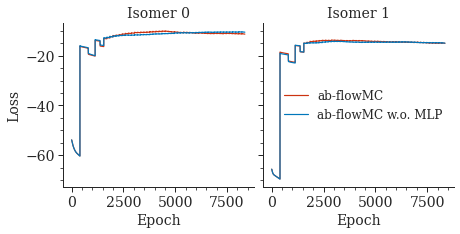

In [52]:
ncols = 2
nrows = 1

figsize=(3.5*ncols, 3*nrows)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

for i in range(2):
    sns.lineplot(flow_losses_df[flow_losses_df['Isomer'] == i],
                 x="Epoch",
                 y="Loss",
                 hue="Method",
                 palette=methods_color,
                 ax=axs[i],
                )
   
    axs[i].set_xlabel('Epoch')
    axs[i].spines[['right', 'top']].set_visible(False)
    axs[i].set_title('Isomer {:d}'.format(i))


axs[0].sharey(axs[1])
plt.setp(axs[1].get_yticklabels(), visible=False)
axs[1].set(ylabel=None)
axs[0].set_ylabel('Loss')
axs[0].legend().remove()
axs[1].legend()

plt.savefig(path_save_figures + f'/figure_5_flows.pdf', 
            bbox_inches='tight',
            dpi=300, 
            facecolor='white',
            transparent=False)

## Loss MLP

In [11]:
mlp_losses_df = pd.read_csv(path_results + '/mlp_losses.csv')

### Full training

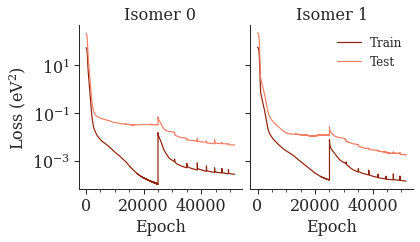

In [12]:
ncols = 2
nrows = 1

figsize=(3*ncols, 3*nrows)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

palette_predictions = dict(zip(['train', 'test'], 
                                    ['#8f230b', '#f27e64']))
for i in range(2):
    sns.lineplot(mlp_losses_df[mlp_losses_df['Isomer'] == i]['Train loss'].values,
                 ax=axs[i],
                 label='Train',
                 color=palette_predictions['train']
                )
    
    sns.lineplot(mlp_losses_df[mlp_losses_df['Isomer'] == i]['Test loss'].values,
                 ax=axs[i],
                 label='Test',
                color=palette_predictions['test']
                )
    
    #axs[i].set_xscale('log')
    axs[i].set_yscale('log')

    axs[i].set_xlabel('Epoch')
    axs[i].spines[['right', 'top']].set_visible(False)

    axs[i].set_title('Isomer {:d}'.format(i))


axs[0].sharey(axs[1])
plt.setp(axs[1].get_yticklabels(), visible=False)
axs[1].set(ylabel=None)
axs[0].set_ylabel('Loss (eV$^{2}$)')
axs[0].legend()
axs[0].legend().remove()

#axs[1].set_xticks([10, 1000, 100000])

plt.savefig(path_save_figures + f'/figure_4a_mlps.pdf', 
            bbox_inches='tight',
            dpi=300, 
            facecolor='white',
            transparent=False)

### Adaptive training

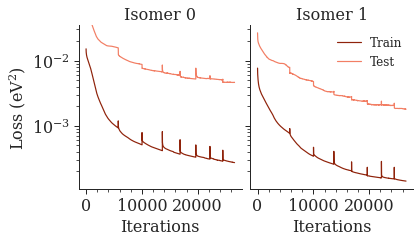

In [13]:
ncols = 2
nrows = 1

figsize=(3*ncols, 3*nrows)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

palette_predictions = dict(zip(['train', 'test'], 
                                    ['#8f230b', '#f27e64']))
for i in range(2):
    sns.lineplot(mlp_losses_df[mlp_losses_df['Isomer'] == i]['Train loss'].values[25000:],
                 ax=axs[i],
                 label='Train',
                 color=palette_predictions['train']
                )
    
    sns.lineplot(mlp_losses_df[mlp_losses_df['Isomer'] == i]['Test loss'].values[25000:],
                 ax=axs[i],
                 label='Test',
                color=palette_predictions['test']
                )
    
    #axs[i].set_xscale('log')
    axs[i].set_yscale('log')

    axs[i].set_xlabel('Iterations')
    axs[i].spines[['right', 'top']].set_visible(False)

    axs[i].set_title('Isomer {:d}'.format(i))


axs[0].sharey(axs[1])
plt.setp(axs[1].get_yticklabels(), visible=False)
axs[1].set(ylabel=None)
axs[0].set_ylabel('Loss (eV$^{2}$)')
axs[0].legend()
axs[0].legend().remove()

#axs[1].set_xticks([10, 1000, 100000])

plt.savefig(path_save_figures + f'/figure_4b_mlps.pdf', 
            bbox_inches='tight',
            dpi=300, 
            facecolor='white',
            transparent=False)

### Ab-flowMM Acceptance rate

In [56]:
accs_mm_df = pd.read_csv(path_results + '/acceptance_rates_mm.csv')

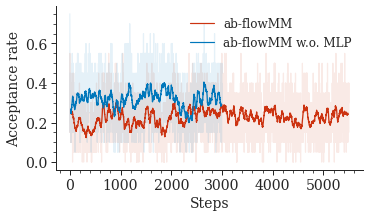

In [57]:
ncols = 1
nrows = 1

figsize=(5.5*ncols, 3*nrows)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.05

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

accs_rate_avg = []

for simulation in accs_mm_df['Method'].unique():
        df = accs_mm_df[accs_mm_df['Method'] == simulation]
        df_new = pd.DataFrame(columns=accs_rate.columns)

        df_new['Acceptance Rate'] = avg_windows(
                df['Acceptance Rate'], 
                window_size=40, 
                axis=1)
        df_new['Step'] = avg_windows(
                df['Step'],
                window_size=40, 
                axis=1)
        df_new['Method'] = simulation
        df_new['Isomer'] = accs_rate['Isomer'].unique()[0]
        accs_rate_avg.append(df_new)

accs_rate_avg = pd.concat(accs_rate_avg)

sns.lineplot(accs_mm_df, 
        x='Step', 
        y='Acceptance Rate', 
        hue='Method',
        palette=methods_color, 
        alpha=0.1,
        ax=axs,
        legend=True) 

sns.lineplot(accs_rate_avg,
        x='Step', 
        y='Acceptance Rate', 
        hue='Method',
        palette=methods_color, 
        linewidth=linewidth*0.65,
        ax=axs,
        legend=False)
    
axs.legend()#handles=patches)

axs.set_xlabel('Steps')
axs.set_ylabel('Acceptance rate')

axs.spines[['right', 'top']].set_visible(False)

plt.savefig(path_save_figures + f'/figure_6_accs_mcmcs.pdf', 
            bbox_inches='tight',
            dpi=300, 
            facecolor='white',
            transparent=False)

### Ab-flowMC acceptance rate comparison with MD

In [58]:
accs_mcmc_md_df = pd.read_csv(path_results + '/acceptance_rates_mcmc_md.csv')

In [59]:
accs_abflowMC_MCMC = pd.concat([accs_rates, accs_mcmc_md_df])
accs_abflowMC_MCMC

,Method,Isomer,Step,Acceptance Rate
0,ab-flowMC,0,0,0.42
1,ab-flowMC,0,1,0.34
2,ab-flowMC,0,2,0.38
3,ab-flowMC,0,3,0.24
4,ab-flowMC,0,4,0.26
...,...,...,...,...
1195,MCMC w. flow from MD,1,595,0.00
1196,MCMC w. flow from MD,1,596,0.02
1197,MCMC w. flow from MD,1,597,0.06
1198,MCMC w. flow from MD,1,598,0.02


In [60]:
accs_abflowMC_MCMC = accs_abflowMC_MCMC[accs_abflowMC_MCMC['Method'] == 'MCMC w. flow from MD']

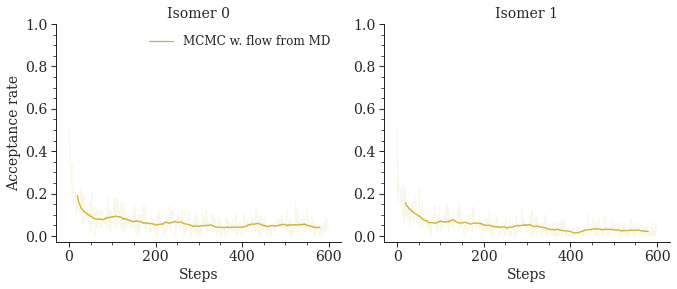

In [61]:
ncols = 2
nrows = 1

figsize=(5.5*ncols, 4*nrows)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=12
linewidth=2
markersize=5
hspace=0.05
wspace=0.15

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
)

accs_rate_avg = []

for isomer in [0, 1]:

        for simulation in accs_abflowMC_MCMC['Method'].unique():
                df = accs_abflowMC_MCMC[accs_abflowMC_MCMC['Method'] == simulation]
                df = df[df['Isomer']==isomer]
                df_new = pd.DataFrame(columns=accs_rate.columns)
        
                df_new['Acceptance Rate'] = avg_windows(
                        df['Acceptance Rate'], 
                        window_size=40, 
                        axis=1)
                df_new['Step'] = avg_windows(
                        df['Step'],
                        window_size=40, 
                        axis=1)
                df_new['Method'] = simulation
                df_new['Isomer'] = isomer
                accs_rate_avg.append(df_new)

accs_rate_avg = pd.concat(accs_rate_avg)

for isomer in [0, 1]:

        sns.lineplot(accs_abflowMC_MCMC[accs_abflowMC_MCMC['Isomer']==isomer], 
                x='Step', 
                y='Acceptance Rate', 
                hue='Method',
                palette=methods_color, 
                alpha=0.1,
                ax=axs[isomer],
                legend=True) 

        sns.lineplot(accs_rate_avg[accs_rate_avg['Isomer']==isomer],
                x='Step', 
                y='Acceptance Rate', 
                hue='Method',
                palette=methods_color, 
                linewidth=linewidth*0.65,
                ax=axs[isomer],
                legend=False)
        
        axs[isomer].legend()#handles=patches)
        axs[isomer].set_xlabel('Steps')
        axs[isomer].set_ylabel('Acceptance rate')
        axs[isomer].spines[['right', 'top']].set_visible(False)
        axs[isomer].set_title('Isomer {:d}'.format(isomer))
        axs[isomer].set_ylim(top=1)

axs[1].sharey(axs[0])
axs[1].set_ylabel(None)
axs[1].legend().remove()